<div style="background-color:#f8f9fa;
    padding:20px;
    border:2px solid #360084;
    border-radius:8px;
    margin:10px 0;">
    <div style="background-color:#fafdf0;
        line-height:2;
        text-align:center;
        border:2px solid #360084;
        padding:15px;
        border-radius:5px;">
        <div style="color:#008B8B;
            font-size:24pt;
            font-weight:700;">
            Linear Regression Residual Diagnosis: Residual Distribution
        </div>
    </div> 
    <div style="margin-top:15px; padding:10px;">
        <strong>Course:</strong> Econometrics<br>
        <strong>Topic:</strong> Linear Regression Residual Analysis<br>
        <strong>Instructor:</strong> Dr. Saad Laouadi<br>
        <strong>Objective:</strong> Using randomly generated synthetic data for visualizing linear regression residuals distribution
    </div>
</div>

---

In [1]:
# ====================================================== #
#            Environment Setup
# ====================================================== #

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from statsmodels.nonparametric.smoothers_lowess import lowess
import warnings

warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (15, 12)
sns.set_style("whitegrid")

print("*"*52)
print("Environment Setup".center(52))
%reload_ext watermark
%watermark -iv -v -ud -a "Dr. Saad Laouadi"
print("*"*52)

****************************************************
                 Environment Setup                  
Author: Dr. Saad Laouadi

Last updated: 2025-06-15

Python implementation: CPython
Python version       : 3.12.11
IPython version      : 9.1.0

scipy      : 1.15.3
seaborn    : 0.13.2
numpy      : 2.3.0
matplotlib : 3.10.0
statsmodels: 0.14.4

****************************************************


In [2]:
print("=== SYNTHETIC DATA FOR DIAGNOSTIC PATTERNS ===")
print("Demonstrating Good vs Bad Patterns in Regression Diagnostics")

# Set random seed for reproducibility
np.random.seed(42)

# Generate sample size
n = 200
x = np.linspace(1, 10, n)

#==============================================================================
# 1. GOOD MODEL - All assumptions satisfied
#==============================================================================

# Good model: Linear relationship with constant variance
y_good = 2 + 3*x + np.random.normal(0, 1, n)
fitted_good = 2 + 3*x
residuals_good = y_good - fitted_good

print(f"\n1. GOOD MODEL: Linear relationship, constant variance")
print(f"   Model: Y = 2 + 3*X + ε, where ε ~ N(0,1)")

#==============================================================================
# NON-NORMAL RESIDUALS DEMONSTRATION
#==============================================================================

# Create different types of non-normal residuals
# Skewed residuals
error_skewed = np.random.exponential(1, n) - 1
y_skewed = 2 + 3*x + error_skewed
fitted_skewed = 2 + 3*x
residuals_skewed = y_skewed - fitted_skewed

# Heavy-tailed residuals (t-distribution)
error_heavy = np.random.standard_t(3, n)  # t-distribution with 3 df
y_heavy = 2 + 3*x + error_heavy
fitted_heavy = 2 + 3*x
residuals_heavy = y_heavy - fitted_heavy

=== SYNTHETIC DATA FOR DIAGNOSTIC PATTERNS ===
Demonstrating Good vs Bad Patterns in Regression Diagnostics

1. GOOD MODEL: Linear relationship, constant variance
   Model: Y = 2 + 3*X + ε, where ε ~ N(0,1)


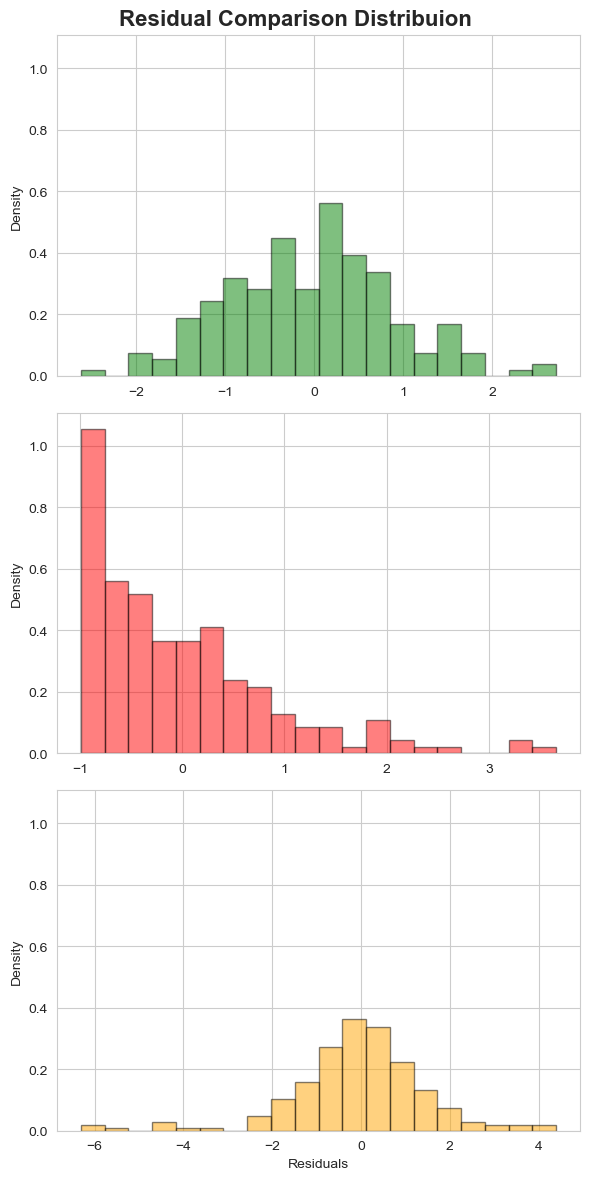

In [3]:
#==============================================================================
#        NON-NORMAL RESIDUALS DISTRIBUTION
#==============================================================================
fig, axes = plt.subplots(3, 1, figsize = (6, 12), sharey=True)

axes[0].hist(residuals_good, bins=20, density=True, alpha=0.5, color='green', label='Normal', edgecolor='black')
axes[1].hist(residuals_skewed, bins=20, density=True, alpha=0.5, color='red', label='Skewed', edgecolor='black')
axes[2].hist(residuals_heavy, bins=20, density=True, alpha=0.5, color='orange', label='Heavy-tailed', edgecolor='black')
axes[2].set_xlabel('Residuals')
axes[0].set_ylabel('Density')
axes[1].set_ylabel('Density')
axes[2].set_ylabel('Density')

plt.suptitle('Residual Comparison Distribuion', fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

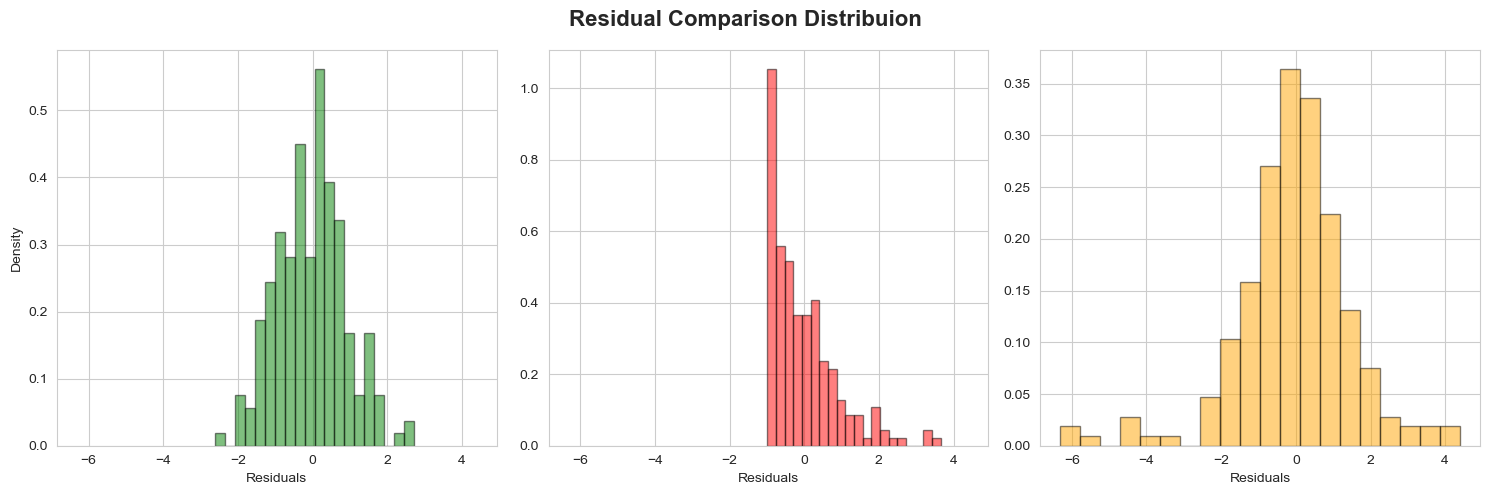

In [4]:
#==============================================================================
#        NON-NORMAL RESIDUALS DISTRIBUTION
#==============================================================================
fig, axes = plt.subplots(1, 3, figsize = (15, 5), sharex=True)

# Combined comparison
axes[0].hist(residuals_good, bins=20, density=True, alpha=0.5, color='green', label='Normal', edgecolor='black')
axes[1].hist(residuals_skewed, bins=20, density=True, alpha=0.5, color='red', label='Skewed', edgecolor='black')
axes[2].hist(residuals_heavy, bins=20, density=True, alpha=0.5, color='orange', label='Heavy-tailed', edgecolor='black')
axes[0].set_xlabel('Residuals')
axes[1].set_xlabel('Residuals')
axes[2].set_xlabel('Residuals')
axes[0].set_ylabel('Density')

plt.suptitle('Residual Comparison Distribuion', fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

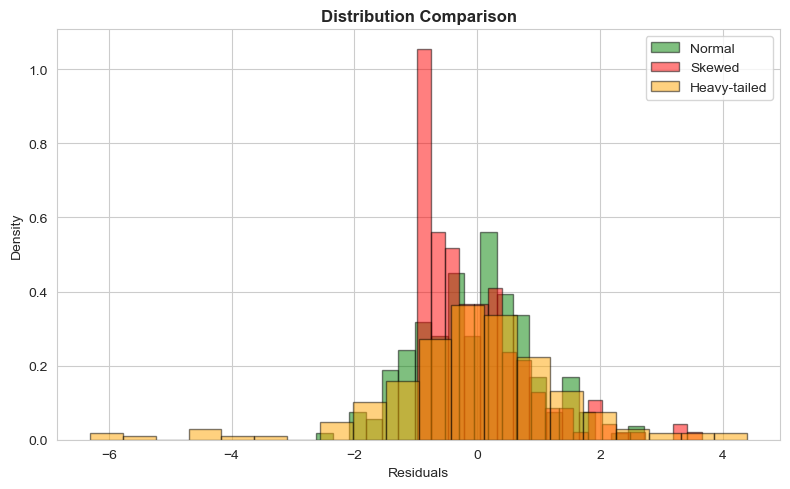

In [5]:
#==============================================================================
#        NON-NORMAL RESIDUALS DISTRIBUTION: Comparison Distribution
#==============================================================================
fig, ax = plt.subplots(1, 1, figsize = (8, 5), sharex=True)

plt.hist(residuals_good,
         bins=20,
         density=True,
         alpha=0.5,
         color='green',
         label='Normal',
         edgecolor='black')

plt.hist(residuals_skewed,
         bins=20,
         density=True,
         alpha=0.5,
         color='red',
         label='Skewed',
         edgecolor='black')

plt.hist(residuals_heavy,
         bins=20,
         density=True,
         alpha=0.5,
         color='orange',
         label='Heavy-tailed',
         edgecolor='black')

plt.title('Distribution Comparison', fontsize=12, fontweight='bold')
plt.xlabel("Residuals")
plt.ylabel("Density")
plt.legend()

plt.tight_layout()
plt.show()

---

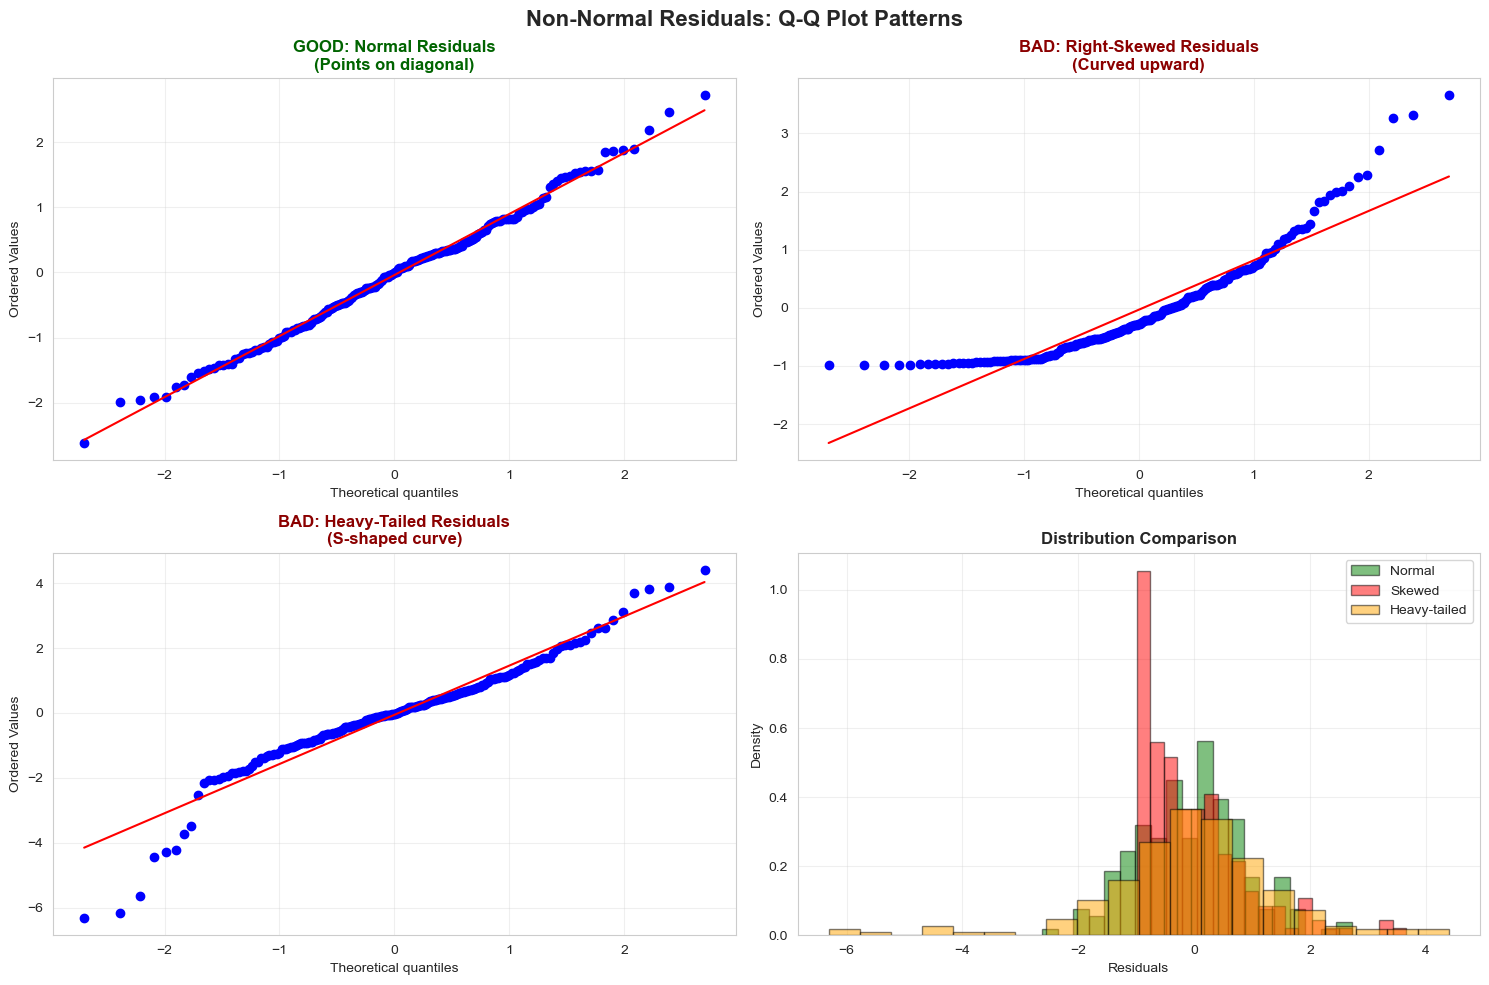

In [6]:
#==============================================================================
#        NON-NORMAL RESIDUALS DISTRIBUTION COMBINED PLOTS WITH QQ-PLOT
#==============================================================================

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Q-Q Plots comparison
stats.probplot(residuals_good, dist="norm", plot=axes[0, 0])
axes[0, 0].set_title('GOOD: Normal Residuals\n(Points on diagonal)', fontsize=12, fontweight='bold', color='darkgreen')
axes[0, 0].grid(True, alpha=0.3)

stats.probplot(residuals_skewed, dist="norm", plot=axes[0, 1])
axes[0, 1].set_title('BAD: Right-Skewed Residuals\n(Curved upward)', fontsize=12, fontweight='bold', color='darkred')
axes[0, 1].grid(True, alpha=0.3)

stats.probplot(residuals_heavy, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('BAD: Heavy-Tailed Residuals\n(S-shaped curve)', fontsize=12, fontweight='bold', color='darkred')
axes[1, 0].grid(True, alpha=0.3)

# Combined comparison
axes[1, 1].hist(residuals_good,
                bins=20,
                density=True,
                alpha=0.5,
                color='green',
                label='Normal',
                edgecolor='black')

axes[1, 1].hist(residuals_skewed,
                bins=20,
                density=True,
                alpha=0.5,
                color='red',
                label='Skewed',
                edgecolor='black')

axes[1, 1].hist(residuals_heavy,
                bins=20,
                density=True,
                alpha=0.5,
                color='orange',
                label='Heavy-tailed',
                edgecolor='black')

axes[1, 1].set_xlabel('Residuals')
axes[1, 1].set_ylabel('Density')
axes[1, 1].set_title('Distribution Comparison',
                     fontsize=12,
                     fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Non-Normal Residuals: Q-Q Plot Patterns',
             fontsize=16,
             fontweight='bold')

plt.tight_layout()
plt.show()